# **Capstone Project: A Bi-Objective Evolutionary Approach to Feature Selection for Customer Value Prediction in Fintech**

# *Statistical Significance Testing*

## MBAI 5600G: Applied Integrative Analytics Capstone Project

### Group 7: Brennan Mason & Mohammad Shah

## Environment Setup

In [ ]:
# Specify base path to local directory
BASE_PATH = "/content/drive/Shareddrives/MBAI Capstone S S26 Group 7/"

In [ ]:
!pip install mlxtend

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Ingestion

In [ ]:
import numpy as np
import pandas as pd

path = BASE_PATH + "p2p-customer-value-prediction/data/processed/cleaned_loans.csv"

loans = pd.read_csv(path)

leaky_cols = [
    "total_pymnt",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "loan_status",
    "last_pymnt_amnt",
    "last_fico_range_low",
    "last_fico_range_high",
    "debt_settlement_flag"
]

loans.drop(columns=leaky_cols, inplace=True)

loans.head()

,funded_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,rar,issue_yr,delinq_recency_bin
0,7000.0,36,0.0789,A,A5,10.0,MORTGAGE,69000.0,Not Verified,debt_consolidation,...,1.0,0.0,231893.0,29326.0,9100.0,24693.0,Cash,7126.312861,2015,Never Delinquent
1,5000.0,36,0.0603,A,A1,1.0,RENT,37000.0,Verified,credit_card,...,0.0,0.0,11423.0,1411.0,8200.0,2625.0,Cash,4944.316301,2012,Never Delinquent
2,10000.0,36,0.0712,A,A3,3.0,RENT,100000.0,Source Verified,debt_consolidation,...,0.0,0.0,196745.0,143072.0,27500.0,161126.0,Cash,9830.124029,2014,Never Delinquent
3,12000.0,36,0.0593,A,A1,NaN,RENT,60000.0,Verified,debt_consolidation,...,0.0,0.0,206735.0,12162.0,76700.0,0.0,Cash,11681.851552,2015,Never Delinquent
4,6700.0,36,0.0532,A,A1,3.0,MORTGAGE,69000.0,Not Verified,debt_consolidation,...,0.0,0.0,204505.0,27059.0,52600.0,35900.0,Cash,6753.795702,2017,Never Delinquent


## Data Preprocessing

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline

# Construct partial preprocessing pipeline for categorical features
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Construct full preprocessing pipeline
preprocessing_pipe = ColumnTransformer(
    transformers=[
        ("cat", cat_pipe, make_column_selector(dtype_include=object)),
        ("num", SimpleImputer(strategy="median"), make_column_selector(dtype_include=np.number))
    ],
    verbose_feature_names_out=False
)

## Data Partitioning

In [ ]:
target_col = "rar"

# Separate feature matrix and target vector
X = loans.drop(target_col, axis=1)
y = loans[target_col].copy()

## Model Development & Evaluation

In [ ]:
from sklearn.model_selection import RepeatedKFold

# Define 5x2 CV procedure
cv = RepeatedKFold(n_splits=2, n_repeats=5, random_state=42)

# Specify eval metric
scoring = "neg_mean_absolute_error"

In [ ]:
import xgboost as xgb
from sklearn.base import clone
from sklearn.model_selection import cross_validate

# Develop and eval baseline model (EC1 - GB)
baseline_regr = make_pipeline(
    clone(preprocessing_pipe),
    xgb.XGBRegressor(
        tree_method="hist",
        n_jobs=-1,
        subsample=0.7,
        random_state=42
    )
)

baseline_scores = cross_validate(
    baseline_regr,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_mae = -baseline_scores["test_score"].mean()
print(f"Baseline MAE: ${baseline_mae:,.2f}")

Baseline MAE: $2,611.67


In [ ]:
# Specify most parsimonious feature set (identified via NSGA-II)
parsimonious_feats = [
    "funded_amnt",
    "term",
    "sub_grade",
    "annual_inc",
    "pub_rec",
    "mths_since_recent_inq",
    "num_accts_ever_120_pd",
    "num_op_rev_tl",
    "pub_rec_bankruptcies",
    "tot_hi_cred_lim",
    "issue_yr",
    "delinq_recency_bin"
]

# Create auto feature selector
feat_selector = ColumnTransformer(
    transformers=[("selector", "passthrough", parsimonious_feats)],
    remainder="drop",
    verbose_feature_names_out=False
)

feat_selector.set_output(transform="pandas")

# Specify best hyperparams (identified via HPO)
learning_rate = np.float64(0.049833191601257244)
n_estimators = 274
max_depth = 7

# Develop and eval final optimized model (EC7 - HPO + GB)
opt_regr = make_pipeline(
    feat_selector,
    clone(preprocessing_pipe),
    xgb.XGBRegressor(
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        max_depth=max_depth,
        tree_method="hist",
        n_jobs=-1,
        subsample=0.7,
        random_state=42
    )
)

opt_scores = cross_validate(
    opt_regr,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

opt_mae = -opt_scores["test_score"].mean()
print(f"Optimized MAE: ${opt_mae:,.2f}")

Optimized MAE: $2,606.42


## Significance Testing

In [ ]:
scores_df = pd.DataFrame({
    "Baseline MAE": -baseline_scores["test_score"],
    "Optimized MAE": -opt_scores["test_score"]
})

display(scores_df)

,Baseline MAE,Optimized MAE
0,2611.542097,2609.485795
1,2615.767112,2601.478020
2,2609.015282,2604.573265
3,2608.667330,2609.058744
4,2599.212216,2599.575635
5,2629.528192,2617.800882
6,2613.480340,2605.874405
7,2608.919795,2602.813181
8,2612.448157,2616.025417
9,2608.082867,2597.494738


======= Summary Statistics =======
       Baseline MAE  Optimized MAE
count     10.000000      10.000000
mean    2611.666339    2606.418008
std        7.683254       6.714798
min     2599.212216    2597.494738
25%     2608.730446    2601.811810
50%     2610.278690    2605.223835
75%     2613.222294    2609.379032
max     2629.528192    2617.800882



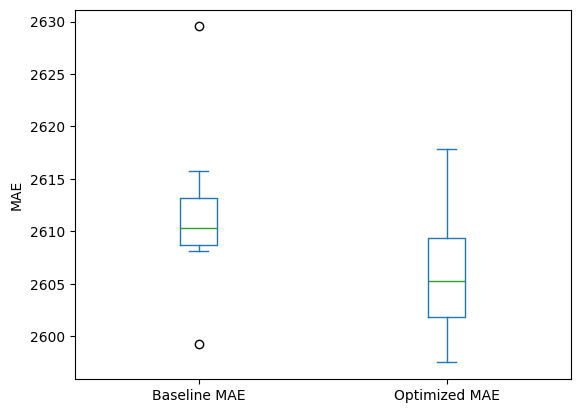

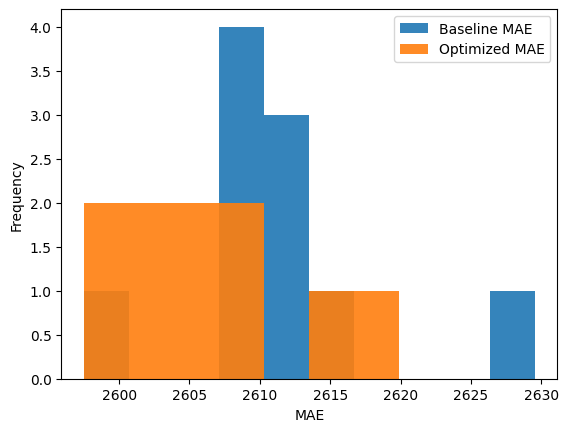

In [ ]:
import matplotlib.pyplot as plt

print("======= Summary Statistics =======")
print(scores_df.describe())

print()

scores_df.plot(kind="box")
plt.ylabel("MAE")
plt.show()

print()

scores_df.plot(kind="hist", alpha=0.9)
plt.xlabel("MAE")
plt.show()

In [ ]:
from scipy.stats import shapiro

def test_normality(data, name, alpha=0.05):
  # Perform Shapiro-Wilk test
  stat, p_val = shapiro(data)

  if p_val > alpha:
    print(f"{name}: Sample is likely normally distributed (p-value = {p_val:.4f})")
  else:
    print(f"{name}: Sample is likely not normally distributed (p-value = {p_val:.4f})")

for col in scores_df.columns:
  test_normality(scores_df[col], col)

Baseline MAE: Sample is likely normally distributed (p-value = 0.0973)
Optimized MAE: Sample is likely normally distributed (p-value = 0.6260)


In [ ]:
from scipy.stats import ttest_rel

# Perform standard paired Student's t-test (flawed methodology)
t_stat, p_val = ttest_rel(scores_df["Baseline MAE"], scores_df["Optimized MAE"])

alpha = 0.05
if p_val > alpha:
  print(f"Samples are likely drawn from populations with the same distribution (p-value = {p_val:.4f})")
else:
  print(f"Samples are likely drawn from populations with different distributions (p-value = {p_val:.4f})")

Samples are likely drawn from populations with different distributions (p-value = 0.0199)


In [ ]:
from mlxtend.evaluate import paired_ttest_5x2cv

# Perform Dietterich's 5x2 CV modified paired Student's t-test
t_stat, p_val = paired_ttest_5x2cv(
    estimator1=baseline_regr,
    estimator2=opt_regr,
    X=X,
    y=y,
    scoring=scoring,
    random_seed=42
)

alpha = 0.05
if p_val > alpha:
  print(f"The difference in performance between the baseline and optimized models is not statistically significant (p-value = {p_val:.4f})\nThe observed improvement is likely due to random chance")
else:
  print(f"The difference in performance between the baseline and optimized models is statistically significant (p-value = {p_val:.4f})\nThe optimization yielded a meaningful improvement")

The difference in performance between the baseline and optimized models is not statistically significant (p-value = 0.8353)
The observed improvement is likely due to random chance
